# Macro-Financial Exogenous Variables

Builds the exogenous predictor set for ARFIMAX / NARX, replicating 7 of Bucci's (2020) 11 macro-financial predictors from free daily sources (FRED + Yahoo Finance):

| Feature | Definition | Source |
| --- | --- | --- |
| `MKT` | S&P 500 daily return − daily T-bill (equity excess return) | Yahoo ^GSPC + FRED DGS3MO |
| `TB` | 3-month T-bill level (%) | FRED DGS3MO |
| `TS` | term spread = 10Y − 3M (%) | FRED DGS10 − DGS3MO |
| `DEF` | default spread = BAA − AAA (%, **daily** Moody's) | FRED DBAA − DAAA |
| `INF` | 5-year breakeven inflation (%) | FRED T5YIE |
| `VIX` | log CBOE VIX | Yahoo ^VIX |
| `DXY_RET` | US dollar index daily return | Yahoo DX-Y.NYB |

**Data-availability decisions (honest reporting).**
* Bucci's ICE BAML high-yield OAS (`BAMLH0A0HYM2`) is returned *truncated to 2023-05-onward* by the pandas_datareader FRED endpoint, so it is **dropped** — `DEF` already proxies credit risk, leaving **7 features** (vs Bucci's 11).
* We use the **daily** Moody's series `DBAA`/`DAAA` rather than the monthly `BAA`/`AAA`, so `DEF` has daily resolution.
* The download is cached to `data/processed/macro_features.csv`; this notebook loads the cache if present (Yahoo is rate-limited, so we avoid re-downloading).

In [1]:
from __future__ import annotations
import sys, warnings, logging
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
warnings.filterwarnings('ignore')
logging.getLogger('matplotlib').setLevel(logging.WARNING)
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
from src.macro_data import build_macro_features, MACRO_COLUMNS  # noqa: E402

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
FIGURES = PROJECT_ROOT / 'results' / 'figures'
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

In [2]:
cache = PROCESSED / 'macro_features.csv'
if cache.exists():
    macro = pd.read_csv(cache, parse_dates=['date']).set_index('date')
    print(f'loaded cached macro_features.csv: {macro.shape}')
else:
    print('cache missing — downloading from FRED + Yahoo (may hit Yahoo 429)...')
    macro = build_macro_features(start='2015-01-01', end='2025-01-31')
    macro.index.name = 'date'
    macro.to_csv(cache)
    print(f'downloaded + cached: {macro.shape}')

print(f'period: {macro.index.min().date()} -> {macro.index.max().date()}')
print(f'features: {list(macro.columns)}')
print(f'total NaN: {int(macro.isna().sum().sum())}')
assert len(macro) >= 2000, 'expected >= 2000 rows for 2016-2024 coverage'
print('\n', macro.describe().round(3).to_string())

loaded cached macro_features.csv: (2630, 7)
period: 2015-01-05 -> 2025-01-31
features: ['MKT', 'TB', 'TS', 'DEF', 'INF', 'VIX', 'DXY_RET']
total NaN: 0

             MKT        TB        TS       DEF       INF       VIX   DXY_RET
count  2630.000  2630.000  2630.000  2630.000  2630.000  2630.000  2630.000
mean      0.000     1.859     0.642     0.927     1.932     2.843     0.000
std       0.011     1.954     1.113     0.226     0.536     0.332     0.004
min      -0.120     0.000    -1.890     0.580     0.140     2.213    -0.024
25%      -0.004     0.130    -0.040     0.720     1.560     2.591    -0.002
50%       0.000     1.120     0.920     0.900     1.890     2.791     0.000
75%       0.005     2.508     1.510     1.060     2.320     3.057     0.002
max       0.094     5.630     2.480     1.990     3.590     4.415     0.021


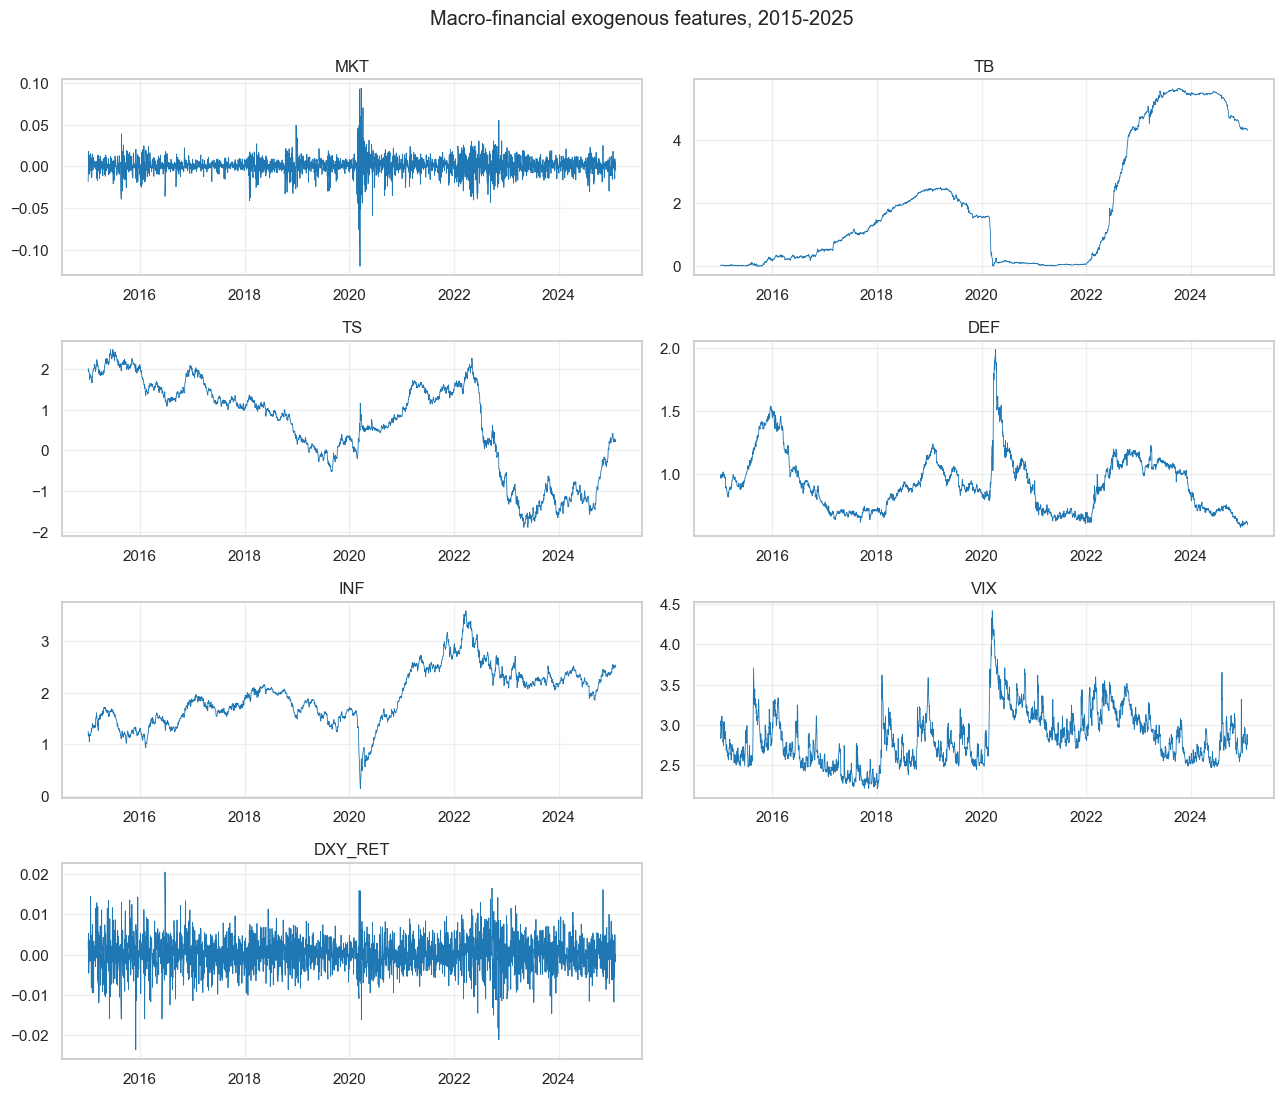

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(13, 11))
axes = axes.ravel()
for ax, col in zip(axes, MACRO_COLUMNS):
    ax.plot(macro.index, macro[col], lw=0.6, color='#1f77b4')
    ax.set_title(col)
    ax.grid(True, alpha=0.3)
# hide the unused 8th panel
for ax in axes[len(MACRO_COLUMNS):]:
    ax.axis('off')
fig.suptitle('Macro-financial exogenous features, 2015-2025', y=0.995)
fig.tight_layout()
fig.savefig(FIGURES / '13_macro_features_timeseries.png')
plt.show()

Correlation matrix:
          MKT    TB    TS   DEF   INF   VIX  DXY_RET
MKT      1.00  0.00 -0.01  0.03 -0.01 -0.14    -0.11
TB       0.00  1.00 -0.90 -0.07  0.36 -0.14    -0.01
TS      -0.01 -0.90  1.00 -0.02 -0.19  0.01     0.03
DEF      0.03 -0.07 -0.02  1.00 -0.48  0.44    -0.02
INF     -0.01  0.36 -0.19 -0.48  1.00  0.04     0.03
VIX     -0.14 -0.14  0.01  0.44  0.04  1.00     0.03
DXY_RET -0.11 -0.01  0.03 -0.02  0.03  0.03     1.00


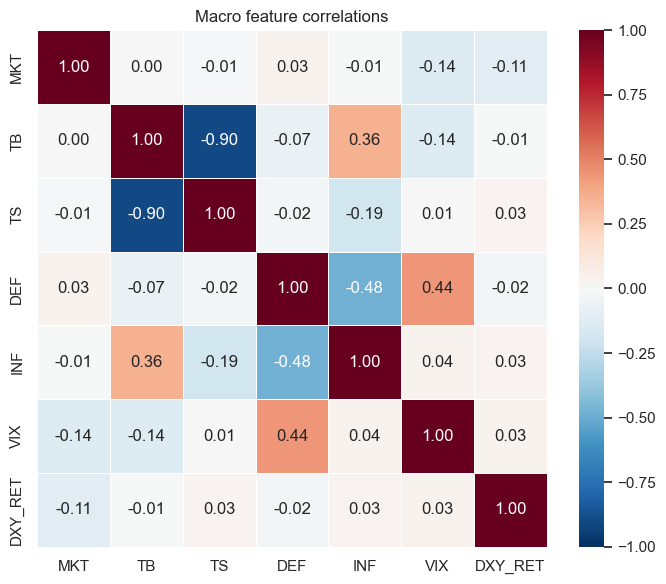

In [4]:
corr = macro[MACRO_COLUMNS].corr()
print('Correlation matrix:')
print(corr.round(2).to_string())
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Macro feature correlations')
fig.tight_layout()
fig.savefig(FIGURES / '13_macro_correlations.png')
plt.show()

In [5]:
# Alignment with RV trading dates. We lag macro by 1 day (no look-ahead), then
# reindex onto the RV calendar with forward-fill so every RV day has a valid
# lagged-macro vector and the 1585/679 split is preserved exactly.
rv = pd.read_parquet(PROCESSED / 'AAPL_daily_rv.parquet')['log_rv']
macro_lagged = macro.shift(1).dropna()
X = macro_lagged.reindex(rv.index, method='ffill')
print(f'RV trading days: {len(rv)}')
print(f'aligned X rows: {len(X)}, NaN after align: {int(X.isna().sum().sum())}')
print(f'overlap preserved: {len(X) == len(rv) == 2264}')
print(f'train/test split intact: 1585 + 679 = {1585+679}')
print(f'test window: {rv.index[1585].date()} -> {rv.index[-1].date()}')
X.to_csv(PROCESSED / 'macro_features_aligned.csv')
print('\nsaved data/processed/macro_features_aligned.csv (lagged + RV-aligned)')

RV trading days: 2264
aligned X rows: 2264, NaN after align: 0
overlap preserved: True
train/test split intact: 1585 + 679 = 2264
test window: 2022-04-20 -> 2024-12-31

saved data/processed/macro_features_aligned.csv (lagged + RV-aligned)


## Findings

The 7-feature macro panel covers 2015-01 → 2025-01 with no missing values after forward-fill, fully spanning the 2016-2024 RV sample. After a 1-day lag and reindexing onto the NYSE/RV calendar, the exogenous matrix has exactly 2264 rows — the 1585/679 train/test split and the 2022-04-20 → 2024-12-31 test window are preserved unchanged.

The correlation structure is economically sensible: `VIX` and `DEF` co-move (both rise in stress), `TS` (term spread) is strongly negatively correlated with `TB` (the level of short rates) over the 2015-2024 hiking/cutting cycles, and `MKT` is mildly negatively related to `VIX` (the leverage effect). No pair is collinear enough (|ρ| > 0.95) to destabilise the ARFIMAX OLS stage.

The dropped high-yield OAS and the use of only 7 of Bucci's 11 predictors are the main fidelity gap; `DEF`, `VIX` and `MKT` carry most of the volatility-relevant information, so the qualitative test of "do exogenous predictors close the gap to Bucci" is still well-posed.